# A small outcome-side example — entirely fictional

Six invented towns, 72 invented personnel records and 18 invented town-period observations show how linkage decisions could enter a municipal analysis table. **None of these values describes the archival source town or historical people in the main walkthrough.** The fictional labels and year indices intentionally cannot be joined to those sources.

The outcome is newly completed dwellings per 1,000 residents. It is a construction **flow**, not a housing stock. One value is deliberately missing. This is a workflow demonstration, not a regression or causal claim about continuity.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd()
staff=pd.read_csv(ROOT/'data/fictional_staff.csv')
housing=pd.read_csv(ROOT/'data/fictional_housing.csv')
assert not staff['person_id'].duplicated().any()
assert not housing.duplicated(['town','period']).any()
assert housing['population'].gt(0).all()
assert housing['completed_dwellings'].dropna().ge(0).all()
display(staff.head())
display(housing.head())

,town,person_id,decision
0,Fictional 01,F01-01,accepted
1,Fictional 01,F01-02,accepted
2,Fictional 01,F01-03,accepted
3,Fictional 01,F01-04,review
4,Fictional 01,F01-05,review


,town,period,population,completed_dwellings
0,Fictional 01,Year 1,15600,85.0
1,Fictional 01,Year 2,15858,148.0
2,Fictional 01,Year 3,15773,164.0
3,Fictional 02,Year 1,19081,193.0
4,Fictional 02,Year 2,19160,174.0


## 1. Aggregate decisions without treating uncertainty as zero continuity

Count distinct earlier personnel. Divide accepted links by that baseline for the **accepted-link share**; report review and not-observed shares separately. These are decision summaries, not true continuity estimates. A failed link need not mean the person left.

decision,accepted,review,not_observed,baseline_people,accepted_share,review_share,not_observed_share
town,,,,,,,
Fictional 01,3,2,7,12,0.250000,0.166667,0.583333
Fictional 02,5,2,5,12,0.416667,0.166667,0.416667
Fictional 03,7,2,3,12,0.583333,0.166667,0.250000
Fictional 04,4,2,6,12,0.333333,0.166667,0.500000
Fictional 05,8,2,2,12,0.666667,0.166667,0.166667
Fictional 06,6,2,4,12,0.500000,0.166667,0.333333


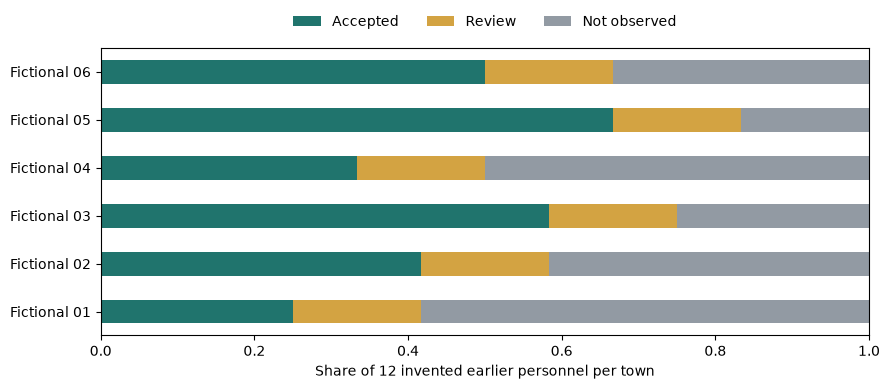

In [2]:
summary=pd.crosstab(staff['town'],staff['decision']).reindex(columns=['accepted','review','not_observed'],fill_value=0)
summary['baseline_people']=summary.sum(axis=1)
for decision in ['accepted','review','not_observed']:
    summary[decision+'_share']=summary[decision]/summary['baseline_people']
assert summary['baseline_people'].eq(12).all()
assert (summary[['accepted_share','review_share','not_observed_share']].sum(axis=1)-1).abs().lt(1e-12).all()
display(summary)
ax=summary[['accepted_share','review_share','not_observed_share']].plot.barh(stacked=True,color=['#20746d','#d3a342','#929aa3'],figsize=(9,4))
ax.set(xlabel='Share of 12 invented earlier personnel per town',ylabel='',xlim=(0,1))
ax.legend(['Accepted','Review','Not observed'],loc='lower center',bbox_to_anchor=(.5,1.02),ncol=3,frameon=False)
plt.tight_layout()
plt.savefig(ROOT/'outputs/fictional_decisions.png',dpi=150)
plt.show()

## 2. Join outcomes and check denominators

Use a many-to-one join from town-period rows to one staff summary per town. Require every town to match. Compute the housing rate using the population observed for that same invented period. Missing construction remains missing, not zero; no annual stock is reconstructed from flows.

In [3]:
panel=housing.merge(summary.reset_index(),on='town',how='left',validate='many_to_one',indicator=True)
assert panel['_merge'].eq('both').all()
panel=panel.drop(columns='_merge')
panel['dwellings_per_1000']=1000*panel['completed_dwellings']/panel['population']
assert panel['dwellings_per_1000'].isna().sum()==1
panel.to_csv(ROOT/'outputs/fictional_panel.csv',index=False,lineterminator='\n')
display(panel[['town','period','population','completed_dwellings','dwellings_per_1000','accepted_share']].round(3))

,town,period,population,completed_dwellings,dwellings_per_1000,accepted_share
0,Fictional 01,Year 1,15600,85.0,5.449,0.250
1,Fictional 01,Year 2,15858,148.0,9.333,0.250
2,Fictional 01,Year 3,15773,164.0,10.398,0.250
3,Fictional 02,Year 1,19081,193.0,10.115,0.417
4,Fictional 02,Year 2,19160,174.0,9.081,0.417
5,Fictional 02,Year 3,19300,82.0,4.249,0.417
6,Fictional 03,Year 1,22661,173.0,7.634,0.583
7,Fictional 03,Year 2,22662,142.0,6.266,0.583
8,Fictional 03,Year 3,22800,165.0,7.237,0.583
9,Fictional 04,Year 1,26145,77.0,2.945,0.333


## 3. Plot coverage and a single-period comparison

The line chart leaves a gap for Fictional 04 in Year 2. The scatter uses only Year 3, so towns are not counted repeatedly as if they were independent observations. The staff share is fixed across these three periods and is not an annual staffing measure. No fitted line or effect estimate is warranted by six invented towns.

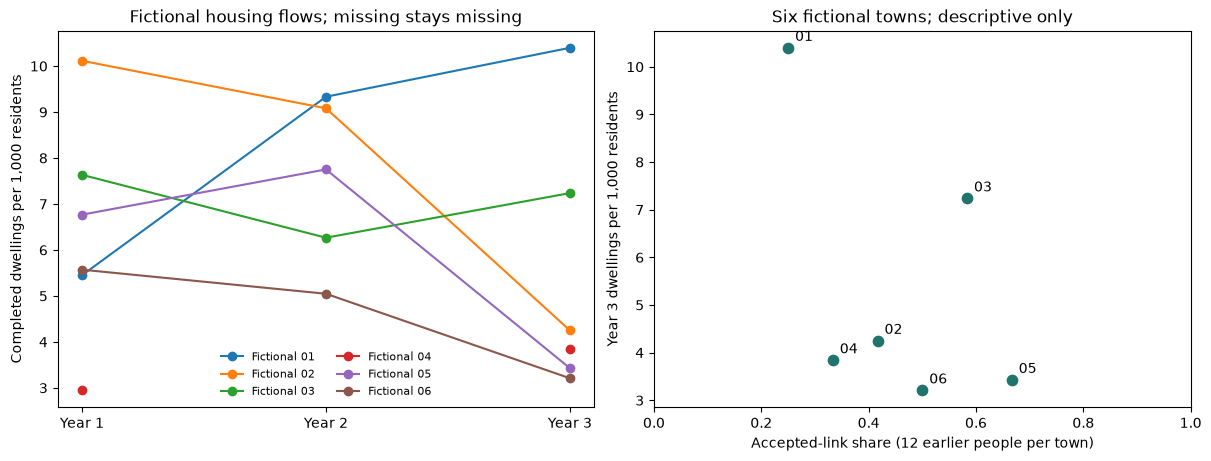

Year 3 complete towns: 6 of 6


In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5),layout='constrained')
for town,g in panel.groupby('town'):
    axes[0].plot([1,2,3],g.sort_values('period')['dwellings_per_1000'],marker='o',label=town)
axes[0].set(xticks=[1,2,3],xticklabels=['Year 1','Year 2','Year 3'],ylabel='Completed dwellings per 1,000 residents',title='Fictional housing flows; missing stays missing')
axes[0].legend(fontsize=8,frameon=False,ncol=2)
cross=panel.loc[panel['period'].eq('Year 3')].dropna(subset=['dwellings_per_1000','accepted_share'])
axes[1].scatter(cross['accepted_share'],cross['dwellings_per_1000'],color='#20746d',s=55)
for row in cross.itertuples():
    axes[1].annotate(row.town[-2:],(row.accepted_share,row.dwellings_per_1000),xytext=(5,5),textcoords='offset points')
axes[1].set(xlabel='Accepted-link share (12 earlier people per town)',ylabel='Year 3 dwellings per 1,000 residents',title='Six fictional towns; descriptive only',xlim=(0,1))
plt.savefig(ROOT/'outputs/fictional_outcomes.png',dpi=150)
plt.show()
print('Year 3 complete towns:',len(cross),'of',panel['town'].nunique())

## Exercise

Replot the Year 3 scatter using `(accepted + review) / baseline_people` on the horizontal axis. Interpret this as the hypothetical case in which every review item is eventually accepted. It is not an upper bound on true continuity because extraction and candidate generation can also miss people.

The small example shows data assembly, explicit denominators, a checked join, preservation of missing values and plots. A research analysis additionally needs validated linkage, consistent outcome definitions and dates, representative coverage and a defensible identification strategy.